# Learning rate for mfcc

In [ ]:
# DATA_DIR = DATA_DIR

TRAIN_DIR = DATA_DIR / 'train'
VALID_DIR = DATA_DIR / 'valid'
TEST_DIR = DATA_DIR / 'test'
NOISE_DIR = DATA_DIR / '_background_noise_'

print("Train:", len(list(TRAIN_DIR.rglob("*.wav"))))
print("Valid:", len(list(VALID_DIR.rglob("*.wav"))))

Train: 51486
Valid: 6828


In [ ]:
from pathlib import Path
import torch
import numpy as np
import random
import pandas as pd
import gc
import itertools

from data.utils import get_datasets, precompute_features
from data.dataset import CachedDataset
from data.transforms import FeatureConfig

from models.train import train, predict
from models.evaluate import evaluate
from models.transformer import Transformer
from models.cnn_transformer import CNNTransformer
from models.utils import set_seed

from plots import (
    plot_f1_training_curves,
    build_summary_df,
    plot_summary_table,
    plot_metrics_comparison,
    plot_f1_comparison,
    plot_confusion_matrix
)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print("Using device:", device)

Using device: cuda


In [ ]:
SEEDS = [0, 1, 2]
EPOCHS = 30
BATCH_SIZE = 64
REPR = "mfcc"
DROPOUT = 0.1

In [ ]:
train_ds, valid_ds, test_ds = get_datasets(
    data_format=REPR,
    train_path=TRAIN_DIR,
    valid_path=VALID_DIR,
    test_path=TEST_DIR,
)

In [ ]:
CACHE_DIR = Path("/kaggle/working/cache_lr_mfcc")

precompute_features(train_ds, CACHE_DIR / "train")
precompute_features(valid_ds, CACHE_DIR / "valid")
precompute_features(test_ds, CACHE_DIR / "test")

train_ds_cached = CachedDataset(CACHE_DIR / "train")
valid_ds_cached = CachedDataset(CACHE_DIR / "valid")
test_ds_cached = CachedDataset(CACHE_DIR / "test")

  0%|          | 0/51486 [00:00<?, ?it/s]

Saved 51486 samples to /kaggle/working/cache_lr_mfcc/train


  0%|          | 0/6828 [00:00<?, ?it/s]

Saved 6828 samples to /kaggle/working/cache_lr_mfcc/valid


  0%|          | 0/6865 [00:00<?, ?it/s]

Saved 6865 samples to /kaggle/working/cache_lr_mfcc/test


In [ ]:
def cnn_transformer_factory(repr_name="mel", dropout=0.1):
    n_features = 40 if repr_name == "mfcc" else 64

    return CNNTransformer(
        n_features=n_features,
        n_timesteps=101,
        num_classes=12,
        base_channels=32,
        d_model=128,
        nhead=4,
        num_layers=4,
        dropout=dropout,
        pooling="mean",
    )

In [ ]:
LEARNING_RATES = [1e-2, 1e-3, 3e-4, 5e-5]

In [ ]:
LR_MFCC_SAVE_PATH = "/kaggle/working/lr_experiment_mfcc.csv"

def learning_rate_experiment_mfcc(
    lr_values,
    seeds=[0, 1, 2],
    epochs=30,
    batch_size=64,
    dropout=0.1,
):
    results = {}
    rows = []

    for lr in lr_values:
        results[lr] = {}

        for seed in seeds:
            print(f"\nLR={lr} | seed={seed}")

            set_seed(seed)

            model = cnn_transformer_factory(
                repr_name=REPR,
                dropout=dropout,
            ).to(device)

            model, history = train(
                model,
                train_ds_cached,
                valid_ds_cached,
                epochs=epochs,
                batch_size=batch_size,
                lr=lr,
                device=device,
            )

            preds_test, labels_test = predict(
                model,
                test_ds_cached,
                device=device,
                batch_size=batch_size,
            )

            test_result = evaluate(
                preds_test,
                labels_test,
                print_report=False,
            )

            results[lr][seed] = {
                "history": history,
                "valid_acc": max(history["valid_acc"]),
                "valid_macro_f1": max(history["valid_f1"]),
                "test_acc": test_result["acc"],
                "test_macro_f1": test_result["macro_f1"],
                "test_weighted_f1": test_result["weighted_f1"],
                "test_cm": test_result["cm"],
            }

            rows.append({
                "lr": lr,
                "seed": seed,
                "batch_size": batch_size,
                "dropout": dropout,
                "best_valid_acc": max(history["valid_acc"]),
                "best_valid_macro_f1": max(history["valid_f1"]),
                "test_acc": test_result["acc"],
                "test_macro_f1": test_result["macro_f1"],
                "test_weighted_f1": test_result["weighted_f1"],
            })

            pd.DataFrame(rows).to_csv(LR_MFCC_SAVE_PATH, index=False)

            del model
            torch.cuda.empty_cache()
            gc.collect()

    return results, pd.DataFrame(rows)

In [ ]:
lr_mfcc_results, df_lr_mfcc = learning_rate_experiment_mfcc(
    lr_values=LEARNING_RATES,
    seeds=SEEDS,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    dropout=DROPOUT,
)

df_lr_mfcc.sort_values("test_macro_f1", ascending=False)


LR=0.01 | seed=0
Epoch 1/30 | Train Loss: 1.5509 | Valid Loss: 1.5640 | Valid Acc: 0.6182 | Valid Macro F1: 0.0637
Epoch 2/30 | Train Loss: 1.5355 | Valid Loss: 1.5638 | Valid Acc: 0.6182 | Valid Macro F1: 0.0637
Epoch 3/30 | Train Loss: 1.5323 | Valid Loss: 1.5733 | Valid Acc: 0.6182 | Valid Macro F1: 0.0637
Epoch 4/30 | Train Loss: 1.5290 | Valid Loss: 1.5628 | Valid Acc: 0.6182 | Valid Macro F1: 0.0637
Epoch 5/30 | Train Loss: 1.5280 | Valid Loss: 1.5600 | Valid Acc: 0.6182 | Valid Macro F1: 0.0637
Epoch 6/30 | Train Loss: 1.5273 | Valid Loss: 1.5614 | Valid Acc: 0.6182 | Valid Macro F1: 0.0637
Epoch 7/30 | Train Loss: 1.5269 | Valid Loss: 1.5626 | Valid Acc: 0.6182 | Valid Macro F1: 0.0637
Epoch 8/30 | Train Loss: 1.5271 | Valid Loss: 1.5674 | Valid Acc: 0.6182 | Valid Macro F1: 0.0637
Epoch 9/30 | Train Loss: 1.5274 | Valid Loss: 1.5625 | Valid Acc: 0.6182 | Valid Macro F1: 0.0637
Epoch 10/30 | Train Loss: 1.5270 | Valid Loss: 1.5629 | Valid Acc: 0.6182 | Valid Macro F1: 0.0637
E

,lr,seed,batch_size,dropout,best_valid_acc,best_valid_macro_f1,test_acc,test_macro_f1,test_weighted_f1
8,0.00030,2,64,0.1,0.961482,0.943410,0.969556,0.956615,0.969474
7,0.00030,1,64,0.1,0.962068,0.943510,0.969556,0.956202,0.969413
6,0.00030,0,64,0.1,0.961629,0.943246,0.967808,0.953499,0.967628
11,0.00005,2,64,0.1,0.957381,0.935820,0.958631,0.936353,0.958535
10,0.00005,1,64,0.1,0.952109,0.929744,0.955863,0.933494,0.955780
9,0.00005,0,64,0.1,0.953720,0.933409,0.956154,0.925370,0.956114
5,0.00100,2,64,0.1,0.942589,0.911438,0.945958,0.917189,0.945409
3,0.00100,0,64,0.1,0.696544,0.406511,0.691770,0.392998,0.627146
2,0.01000,2,64,0.1,0.618190,0.063671,0.621704,0.063894,0.476679
1,0.01000,1,64,0.1,0.618190,0.063671,0.621704,0.063894,0.476679


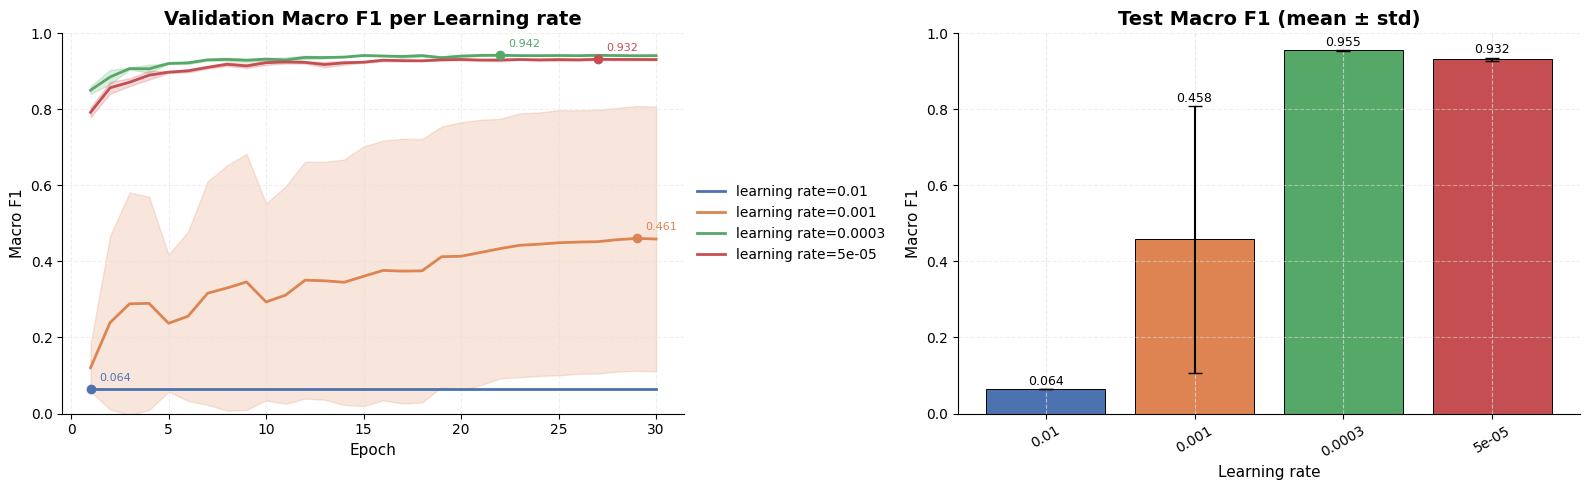

In [ ]:
plot_f1_comparison(
    lr_mfcc_results,
    param_name="Learning rate",
    param_name_short="learning rate"
)